In [4]:
import os
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import cv2
import lime
from lime import lime_image
import shap
from captum.attr import IntegratedGradients
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Loading the dataset

In [6]:
DATA_ROOT = "/kaggle/input/datasets/malakkhaled202300369/adni-data/adni_nifti_preprocessed"

all_paths  = []
all_labels = []

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f"\nTotal images: {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Classes found: ['AD', 'CN', 'MCI']

Total images: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


In [7]:
OUTPUT_DIR = "/kaggle/working/preprocessed_densenet"
CKPT_DIR    = "/kaggle/working/checkpoints_densent"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE = 224
TRAIN_RATIO = 0.80
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 0.001         
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-3 
PATIENCE = 10
LABEL_SMOOTHING = 0.1 

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [8]:
all_paths = []
all_labels = []

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")
print(f"Number of classes: {len(CLASS_NAMES)}")

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f"\nTotal images: {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Classes found: ['AD', 'CN', 'MCI']
Number of classes: 3

Total images: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


# Splitting (Train, Validation, and Test)

In [9]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")


Train: 6809 | Val: 851 | Test: 852


In [10]:
train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

overlap_train_val = len(train_set & val_set)
overlap_train_test = len(train_set & test_set)
overlap_val_test = len(val_set & test_set)

print(f"Train-Val overlap: {overlap_train_val}")
print(f"Train-Test overlap: {overlap_train_test}")
print(f"Val-Test overlap: {overlap_val_test}")

if overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0:
    print("✓ No data leakage")
else:
    print("✗ Data leakage detected!")

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
✓ No data leakage


In [11]:
print("\nClass distribution:")
for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}: {dict(sorted(c.items()))}")


Class distribution:
  train: {0: 1147, 1: 1873, 2: 3789}
  val: {0: 143, 1: 234, 2: 474}
  test: {0: 144, 1: 234, 2: 474}


# Saving Tensors

In [12]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)

    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base_fname = os.path.splitext(os.path.basename(path))[0]
        tracking_key = f"{cls_name}_{base_fname}"

        if tracking_key in filename_usage:
            filename_usage[tracking_key] += 1
            unique_fname = f"{base_fname}_dup{filename_usage[tracking_key]}.pt"
        else:
            filename_usage[tracking_key] = 0
            unique_fname = f"{base_fname}.pt"

        out_path = os.path.join(out_dir, unique_fname)

        img = Image.open(path).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = transforms.ToTensor()(img)
        tensor = (tensor * 255).byte()
        torch.save(tensor, out_path)

save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths, val_labels, "val")
save_tensors(test_paths, test_labels, "test")

print("All tensors saved.")

Saving test: 100%|██████████| 852/852 [00:04<00:00, 188.44it/s]

All tensors saved.


# Dataset Class

In [13]:
pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

pt_lookup built: 0 entries


In [14]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith(".pt"):
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label

    def get_labels(self):
        return [s[1] for s in self.samples]

In [15]:
train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"), CLASS_NAMES)
test_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"), CLASS_NAMES)

print(f"\nDataset sizes:")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Dataset sizes:
Train: 6809 | Val: 851 | Test: 852


# Weighted Sampling For Class Imbalance

In [16]:
train_labels_list = train_ds.get_labels()
class_counts = Counter(train_labels_list)
print(f"\nTraining class distribution: {dict(sorted(class_counts.items()))}")


Training class distribution: {0: 1147, 1: 1873, 2: 3789}


In [17]:
sample_weights = [1.0 / class_counts[label] for label in train_labels_list]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Model

In [18]:
def build_densenet_multiclass(num_classes):
    """Build DenseNet-121 for multi-class classification"""
    model = models.densenet121(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),            
        nn.Linear(in_features, num_classes)
    )
    return model

In [19]:
model = build_densenet_multiclass(num_classes=len(CLASS_NAMES)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(         
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)
scaler = torch.amp.GradScaler()

print(f"\nModel initialized with {len(CLASS_NAMES)} output classes")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model initialized with 3 output classes
Total parameters: 6,956,931


# Training

In [20]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    """Run one epoch of training or validation"""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels

In [21]:
from sklearn.metrics import precision_recall_fscore_support

ckpt_path = os.path.join(CKPT_DIR, "best_densenet_multiclass.pt")

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_ctr = 0

print(f"  TRAINING MULTI-CLASS CLASSIFIER")
print(f"  Classes: {CLASS_NAMES}")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(
        train_loader, model, criterion, optimizer, scaler,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]"
    )

    vl_loss, vl_acc, val_preds, val_labels = run_epoch(
        val_loader, model, criterion,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]"
    )

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_labels, val_preds, average=None, zero_division=0
    )

    print(f"Epoch {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | "
          f"val loss={vl_loss:.4f} acc={vl_acc*100:.2f}%")
    print(f"  Val per-class F1: {[f'{f:.3f}' for f in f1]}")

    scheduler.step()

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        patience_ctr = 0
        print(f"  ✓ Best val_acc={best_val_acc*100:.2f}% — saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")

  TRAINING MULTI-CLASS CLASSIFIER
  Classes: ['AD', 'CN', 'MCI']


Epoch 01 | train loss=1.0309 acc=48.64% | val loss=1.2131 acc=34.08%
  Val per-class F1: ['0.376', '0.567', '0.082']
  ✓ Best val_acc=34.08% — saved.


Epoch 02 | train loss=0.9769 acc=53.68% | val loss=0.9814 acc=49.71%
  Val per-class F1: ['0.438', '0.498', '0.527']
  ✓ Best val_acc=49.71% — saved.


Epoch 03 | train loss=0.9181 acc=58.41% | val loss=1.0685 acc=42.77%
  Val per-class F1: ['0.563', '0.534', '0.170']


Epoch 04 | train loss=0.8784 acc=62.67% | val loss=1.6562 acc=29.38%
  Val per-class F1: ['0.337', '0.344', '0.202']


...

Epoch 36 | train loss=0.3155 acc=99.22% | val loss=0.3037 acc=99.41%
  Val per-class F1: ['0.993', '0.994', '0.995']


Epoch 37 | train loss=0.3076 acc=99.59% | val loss=0.3016 acc=99.65%
  Val per-class F1: ['0.997', '0.996', '0.997']
  ✓ Best val_acc=99.65% — saved.


Epoch 38 | train loss=0.3114 acc=99.46% | val loss=0.3010 acc=99.65%
  Val per-class F1: ['1.000', '0.994', '0.997']


Epoch 39 | train loss=0.3073 acc=99.50% | val loss=0.3004 acc=99.53%
  Val per-class F1: ['0.996', '0.994', '0.996']


Epoch 40 | train loss=0.3054 acc=99.74% | val loss=0.3004 acc=99.65%
  Val per-class F1: ['0.996', '0.996', '0.997']

Best validation accuracy: 99.65%


# Curves

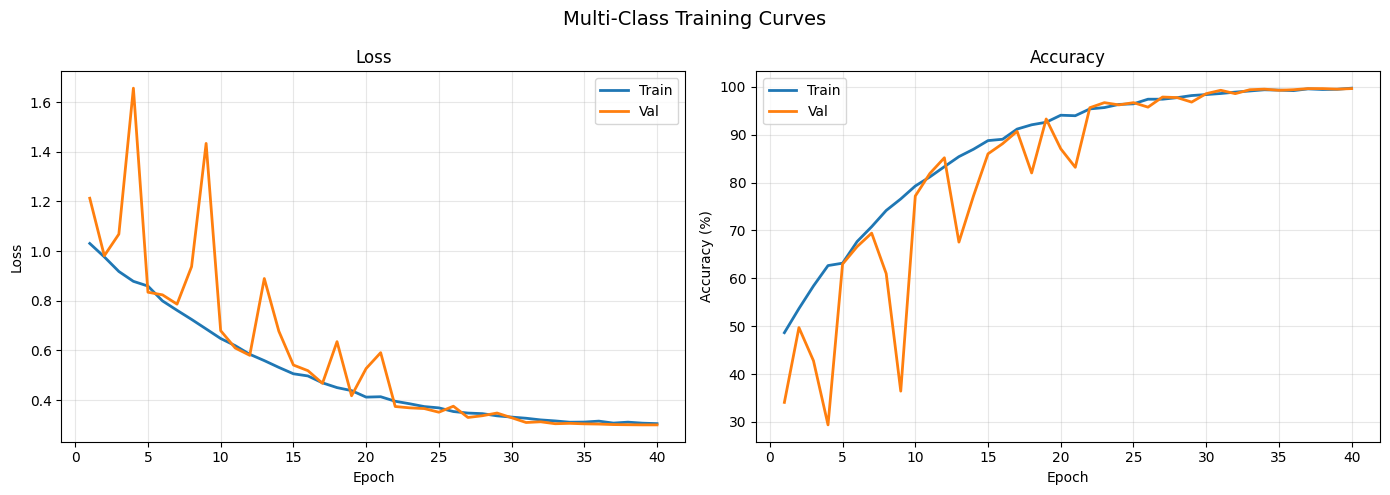

In [30]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Multi-Class Training Curves', fontsize=14)

axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']], label='Val', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "curves_multiclass.png"), dpi=150)
plt.show()

# Test Evaluation

In [31]:
print(f"\n{'='*60}")
print(f"  TEST EVALUATION")
print(f"{'='*60}\n")

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

test_loss, test_acc, test_preds, test_labels = run_epoch(
    test_loader, model, criterion, desc="Testing"
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%\n")


  TEST EVALUATION



Test Loss: 0.3029
Test Accuracy: 99.65%



# Classification Report

In [34]:
print("Classification Report:")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0
)

print("\nPer-Class Metrics Summary:")
print("-"*60)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:15s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | "
          f"F1: {f1[i]:.4f} | Support: {support[i]}")

macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)
print(f"\nMacro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

          AD     1.0000    0.9931    0.9965       144
          CN     1.0000    0.9915    0.9957       234
         MCI     0.9937    1.0000    0.9968       474

    accuracy                         0.9965       852
   macro avg     0.9979    0.9948    0.9964       852
weighted avg     0.9965    0.9965    0.9965       852


Per-Class Metrics Summary:
------------------------------------------------------------
AD              | Precision: 1.0000 | Recall: 0.9931 | F1: 0.9965 | Support: 144
CN              | Precision: 1.0000 | Recall: 0.9915 | F1: 0.9957 | Support: 234
MCI             | Precision: 0.9937 | Recall: 1.0000 | F1: 0.9968 | Support: 474

Macro F1-Score: 0.9964
Weighted F1-Score: 0.9965


# Confusion Matrix

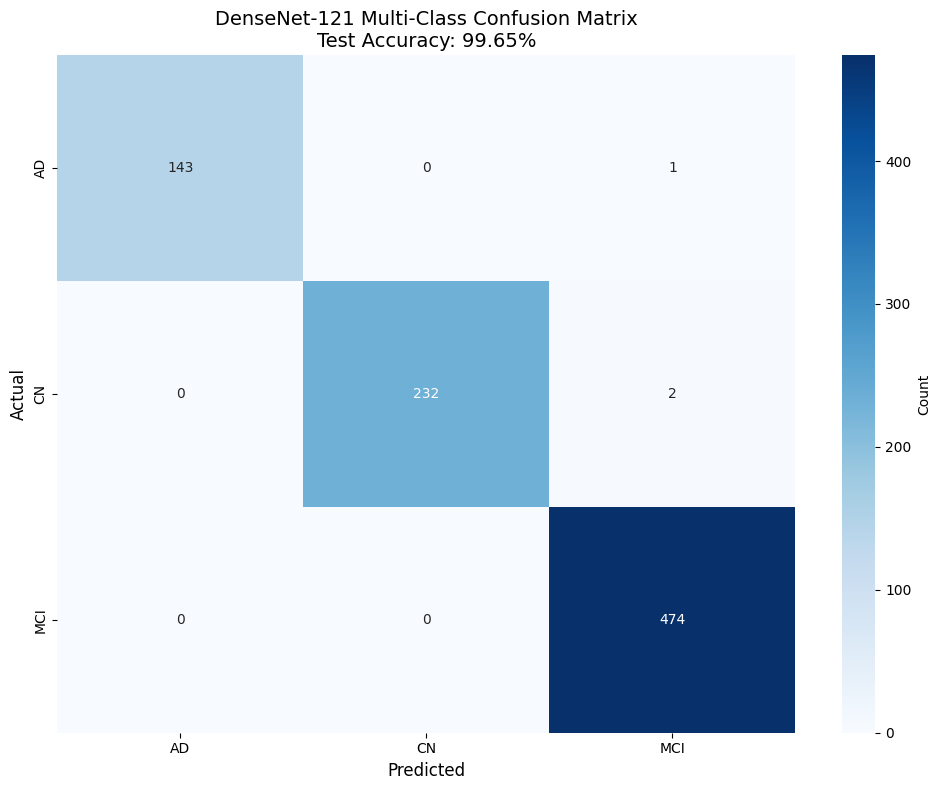

In [35]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'DenseNet-121 Multi-Class Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%',
          fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "cm_multiclass.png"), dpi=150)
plt.show()

# Saving Results

In [36]:
results = {
    'model': 'DenseNet-121',
    'num_classes': len(CLASS_NAMES),
    'class_names': CLASS_NAMES,
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_metrics': {
        cls: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1': float(f1[i]),
            'support': int(support[i])
        }
        for i, cls in enumerate(CLASS_NAMES)
    },
    'confusion_matrix': cm.tolist(),
    'best_val_acc': float(best_val_acc),
    'hyperparameters': {
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LR,
        'momentum': MOMENTUM,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs': len(history['train_loss']),
        'patience': PATIENCE
    }
}

results_path = os.path.join(CKPT_DIR, "multiclass_results.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Results saved to: {results_path}")
print(f"✓ Model checkpoint saved to: {ckpt_path}")

print("\n" + "="*60)
print("  TRAINING COMPLETE")
print("="*60)


✓ Results saved to: /kaggle/working/checkpoints_densent/multiclass_results.json
✓ Model checkpoint saved to: /kaggle/working/checkpoints_densent/best_densenet_multiclass.pt

  TRAINING COMPLETE


In [38]:
import os
import shutil
from IPython.display import FileLink, display

print("="*60)
print("Packaging all files into a single ZIP...")
print("="*60)

import joblib
save_path = os.path.join(CKPT_DIR, 'DenseNet(ScanLevel)_model_final.pkl')
joblib.dump(model, save_path)

zip_path = "/kaggle/temp/all_project_outputs.zip"
os.makedirs("/kaggle/temp", exist_ok=True)
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/kaggle/working')

final_zip_path = "/kaggle/working/all_project_outputs.zip"
shutil.move(zip_path, final_zip_path)

print("\n✅ Done! Click the link below to download everything in one file:")
display(FileLink("all_project_outputs.zip"))

Packaging all files into a single ZIP...

✅ Done! Click the link below to download everything in one file:


/kaggle/working/all_project_outputs.zip

# XAI

In [39]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

def load_sample_image(dataset, idx=0):
    img_tensor, label = dataset[idx]
    img_display = (denormalize(img_tensor).permute(1,2,0).numpy() * 255).astype(np.uint8)
    return img_tensor, img_display, label

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

sample_indices = {cls: None for cls in CLASS_NAMES}
for i, (_, lbl) in enumerate(test_ds.samples):
    cls = CLASS_NAMES[lbl]
    if sample_indices[cls] is None:
        sample_indices[cls] = i
    if all(v is not None for v in sample_indices.values()):
        break

print("Sample indices:", sample_indices)

Sample indices: {'AD': 0, 'CN': 144, 'MCI': 378}


# LIME


LIME: AD


  0%|          | 0/1000 [00:00<?, ?it/s]

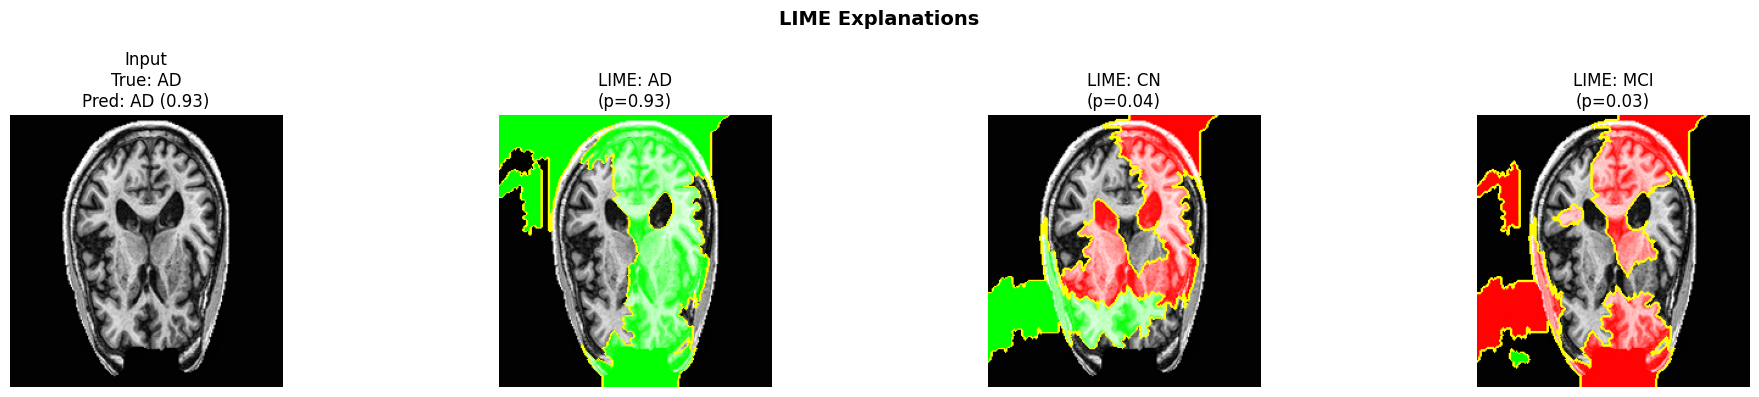


LIME: CN


  0%|          | 0/1000 [00:00<?, ?it/s]

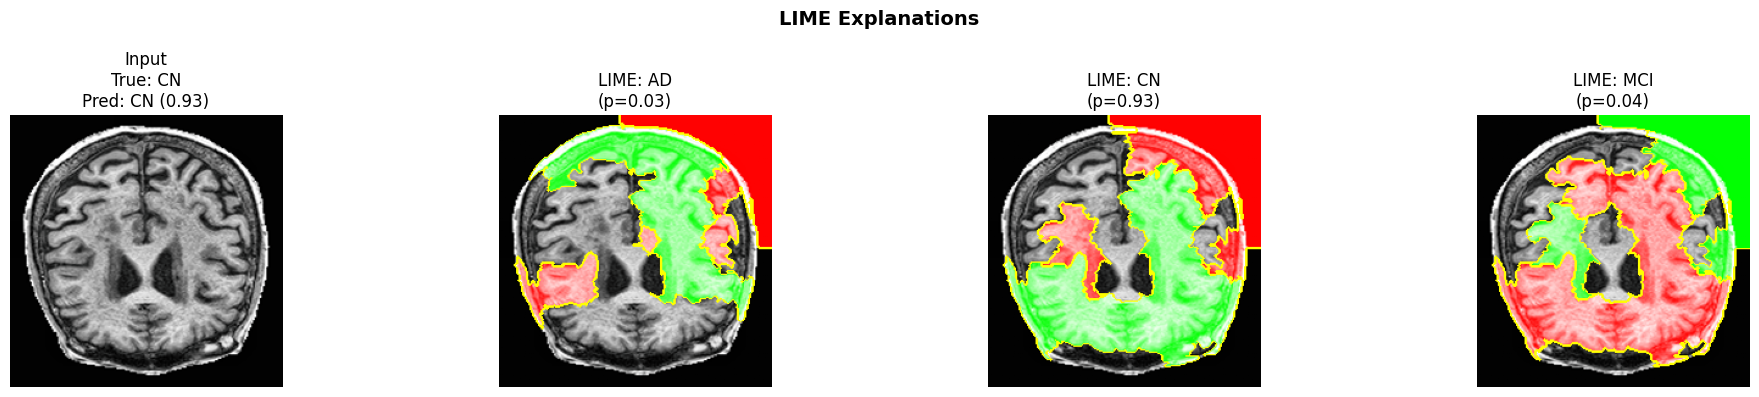


LIME: MCI


  0%|          | 0/1000 [00:00<?, ?it/s]

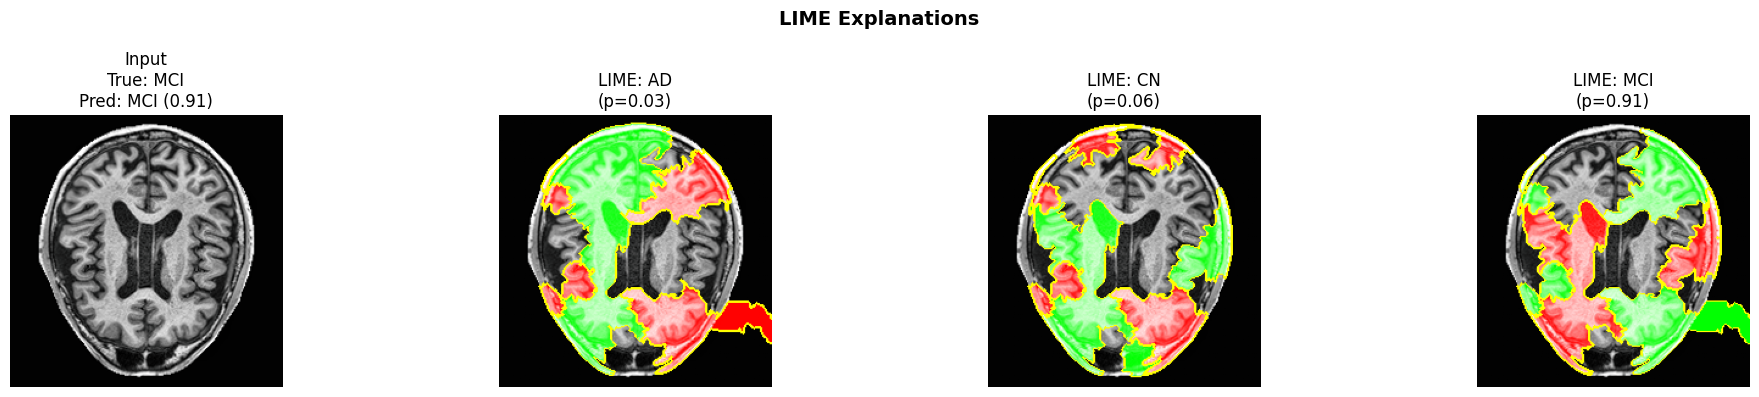

In [40]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_explain(model, dataset, sample_idx, num_samples=1000):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)

    def batch_predict(images):
        model.eval()
        batch = []
        for img in images:
            t = transforms.ToTensor()(img)
            t = normalize(t)
            batch.append(t)
        batch = torch.stack(batch).to(device)
        with torch.no_grad():
            logits = model(batch)
        return F.softmax(logits, dim=1).cpu().numpy()

    explainer = lime_image.LimeImageExplainer(random_state=42)
    explanation = explainer.explain_instance(
        img_display,
        batch_predict,
        top_labels=len(CLASS_NAMES),
        hide_color=0,
        num_samples=num_samples
    )

    pred_probs = batch_predict([img_display])[0]
    pred_label = pred_probs.argmax()

    fig, axes = plt.subplots(1, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 4))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        temp, mask = explanation.get_image_and_mask(
            cls_idx,
            positive_only=False,
            num_features=10,
            hide_rest=False
        )
        axes[i + 1].imshow(mark_boundaries(temp / 255.0, mask))
        axes[i + 1].set_title(f"LIME: {CLASS_NAMES[cls_idx]}\n(p={pred_probs[cls_idx]:.2f})")
        axes[i + 1].axis("off")

    plt.suptitle("LIME Explanations", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return explanation

for cls, idx in sample_indices.items():
    print(f"\nLIME: {cls}")
    lime_explain(model, test_ds, idx, num_samples=1000)

# Grad-Cam


Grad-CAM: AD


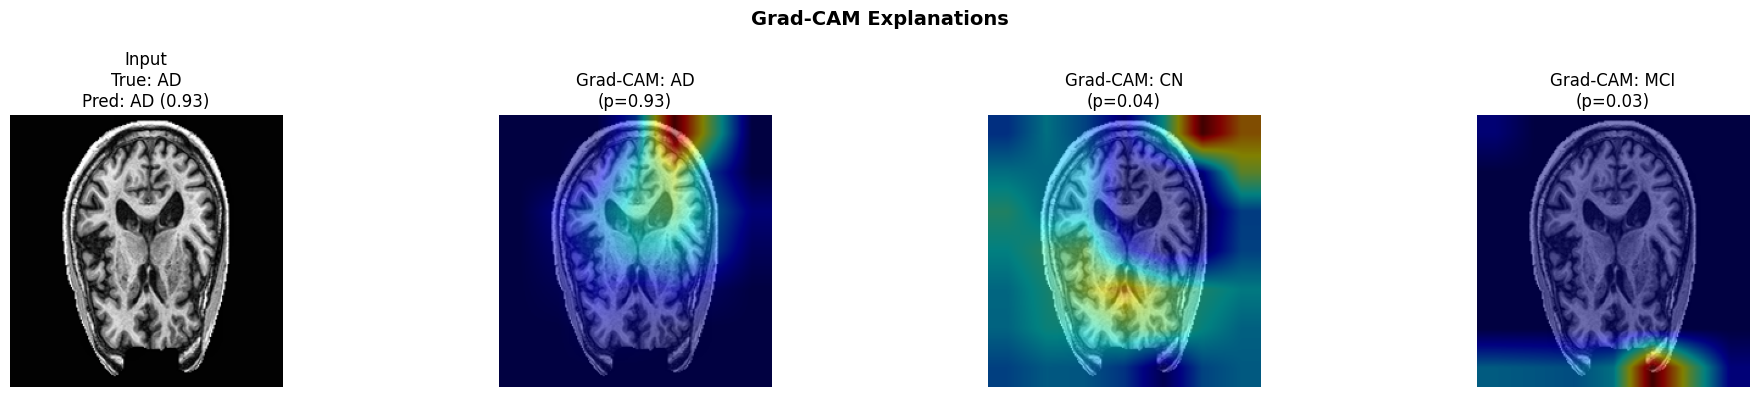


Grad-CAM: CN


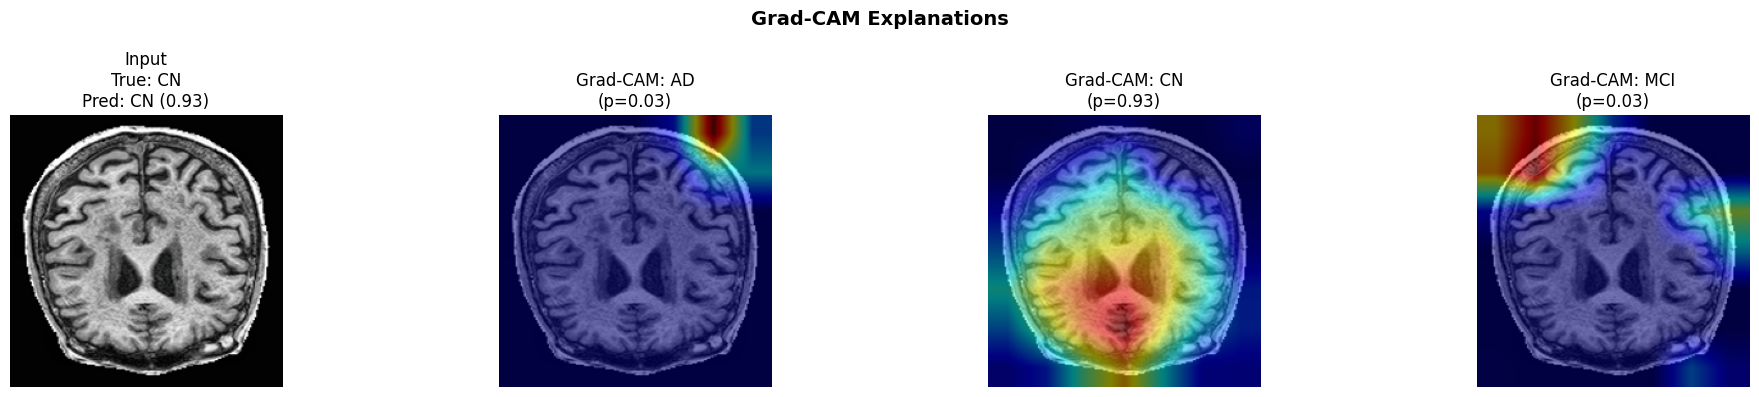


Grad-CAM: MCI


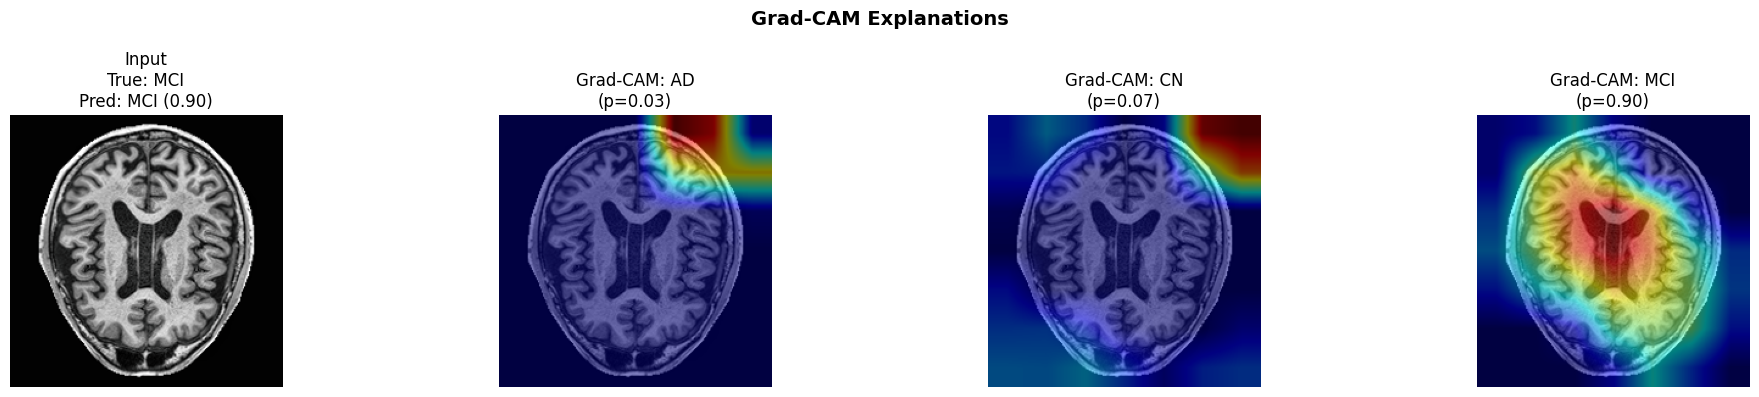

In [51]:
import cv2

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = self.model.features.denseblock4

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device).requires_grad_(True)

        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()

        cam = cv2.resize(cam, (input_tensor.shape[-1], input_tensor.shape[-2]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

def gradcam_explain(model, dataset, sample_idx):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)

    with torch.no_grad():
        pred_probs = F.softmax(model(img_tensor.unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
    pred_label = pred_probs.argmax()

    gcam = GradCAM(model)

    fig, axes = plt.subplots(1, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 4))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        cam, _ = gcam.generate(img_tensor.clone(), target_class=cls_idx)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (0.5 * img_display.astype(float) + 0.5 * heatmap.astype(float)).astype(np.uint8)

        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"Grad-CAM: {CLASS_NAMES[cls_idx]}\n(p={pred_probs[cls_idx]:.2f})")
        axes[i + 1].axis("off")

    plt.suptitle("Grad-CAM Explanations", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

for cls, idx in sample_indices.items():
    print(f"\nGrad-CAM: {cls}")
    gradcam_explain(model, test_ds, idx)

# Saliency


Saliency: AD 


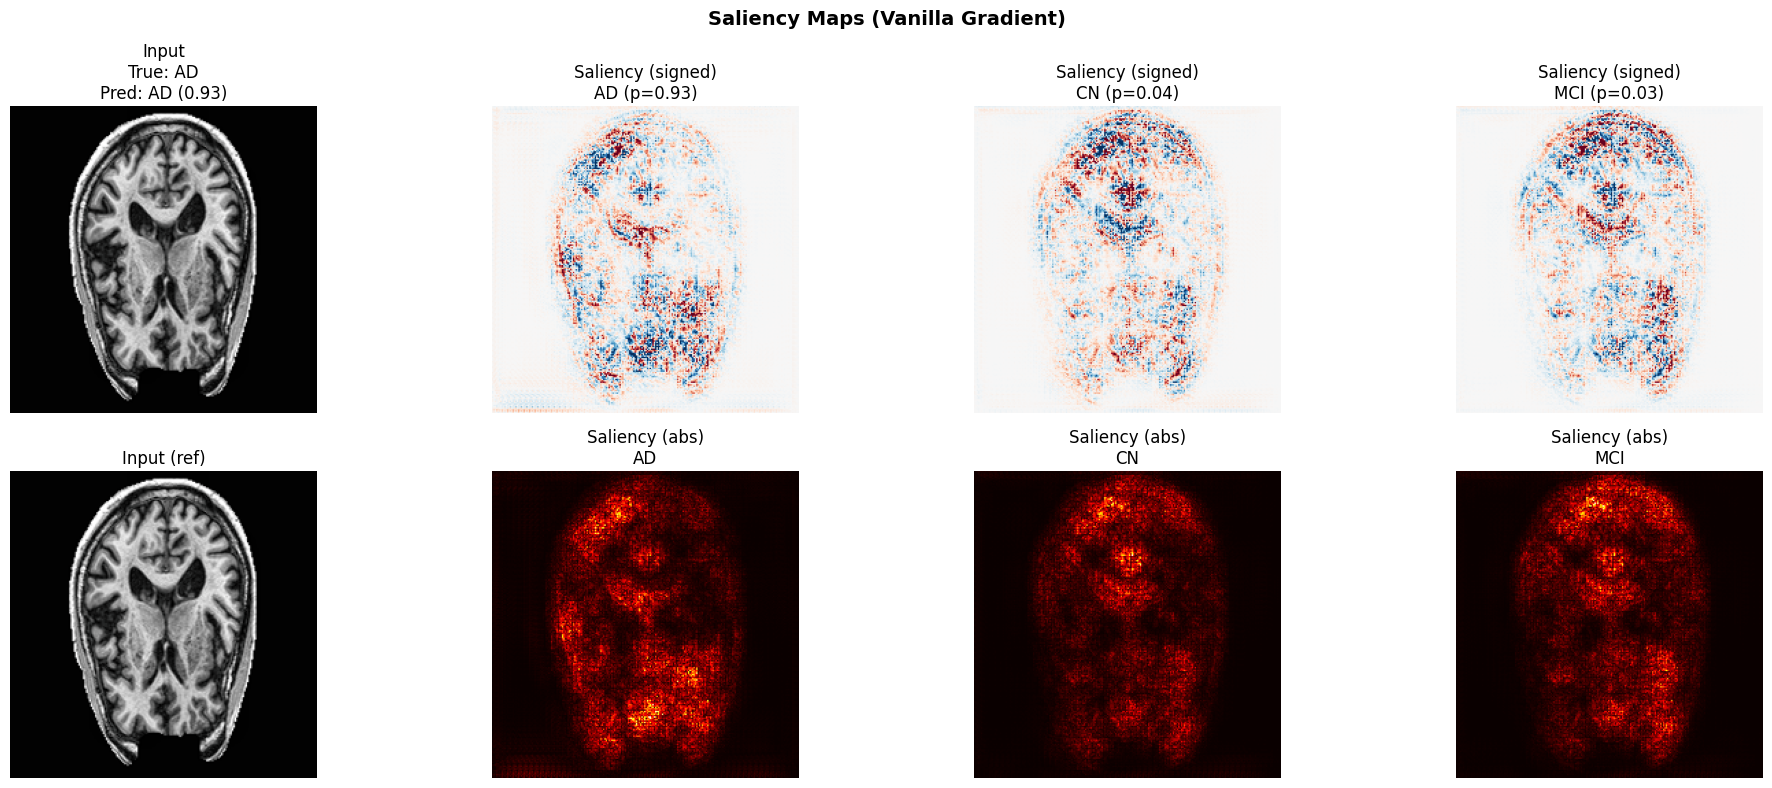


Saliency: CN 


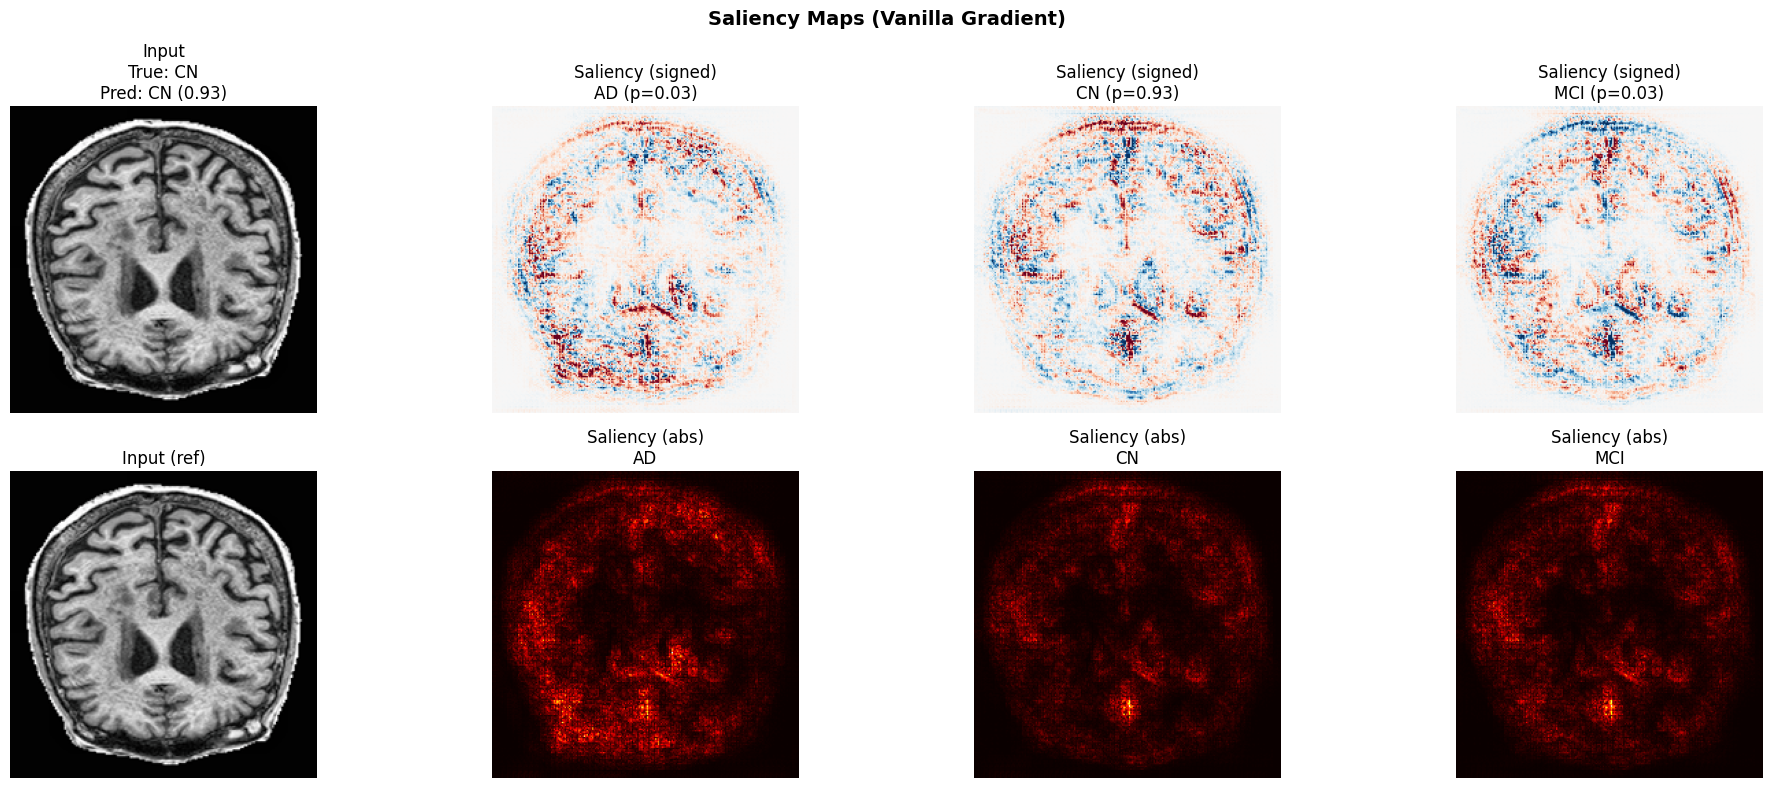


Saliency: MCI 


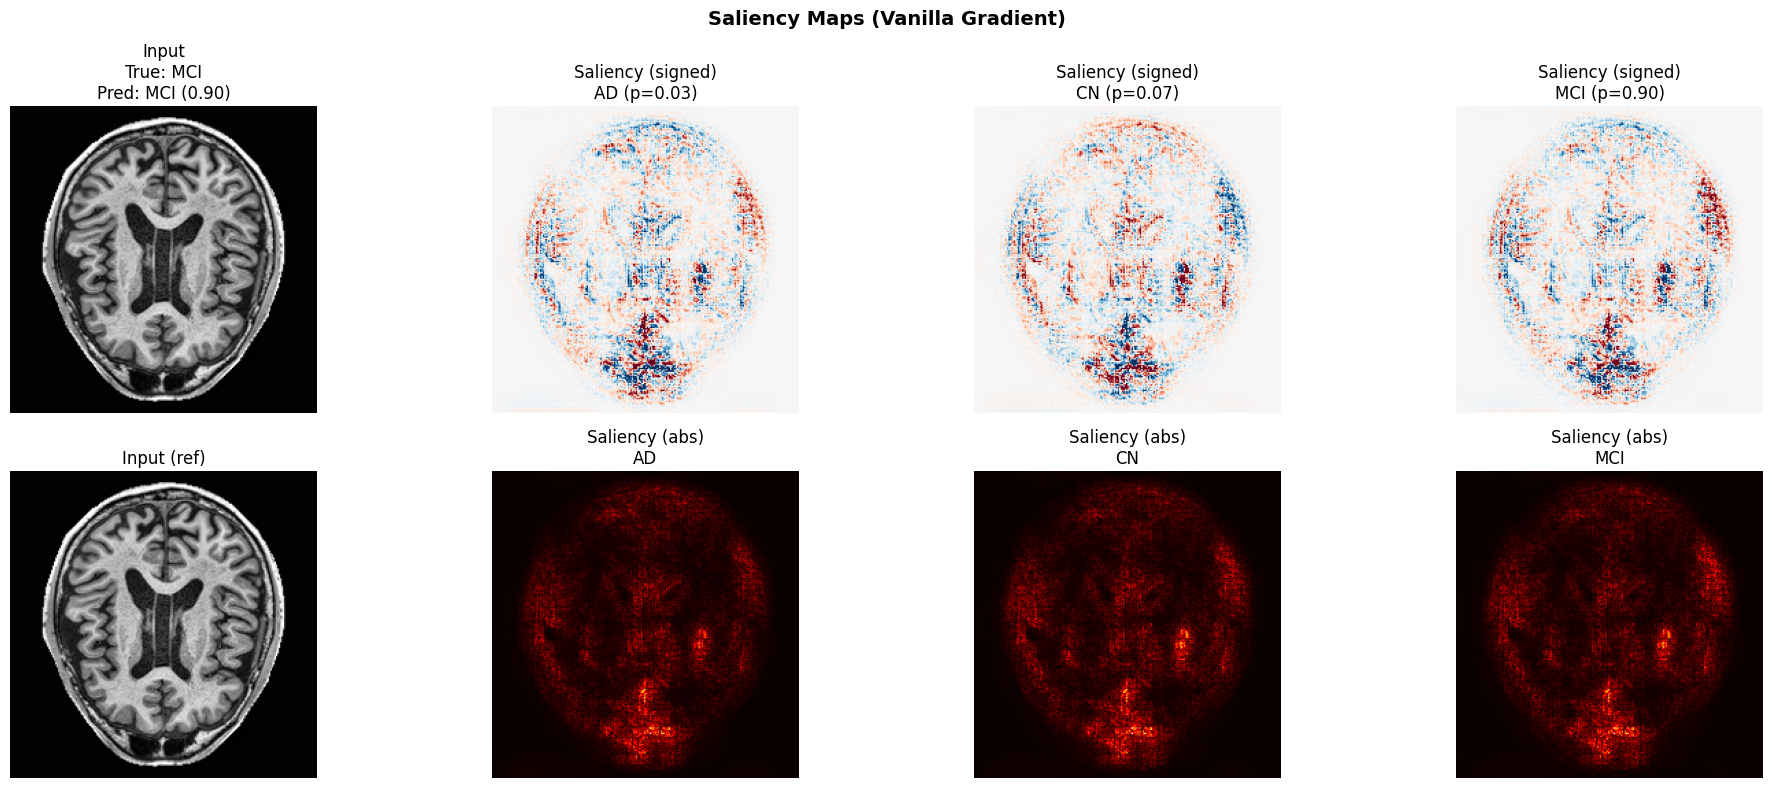

In [73]:
from captum.attr import Saliency

def saliency_explain(model, dataset, sample_idx):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)

    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_probs = F.softmax(model(input_tensor), dim=1).cpu().numpy()[0]
    pred_label = pred_probs.argmax()

    sal = Saliency(model)

    fig, axes = plt.subplots(2, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 8))

    axes[0, 0].imshow(img_display)
    axes[0, 0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0, 0].axis("off")
    axes[1, 0].imshow(img_display)
    axes[1, 0].set_title("Input (ref)")
    axes[1, 0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        attr = sal.attribute(input_tensor, target=cls_idx, abs=False)
        attr_np = attr.squeeze().cpu().numpy()

        signed = attr_np.mean(axis=0)
        vmax = np.percentile(np.abs(signed), 99)
        axes[0, i + 1].imshow(signed, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[0, i + 1].set_title(f"Saliency (signed)\n{CLASS_NAMES[cls_idx]} (p={pred_probs[cls_idx]:.2f})")
        axes[0, i + 1].axis("off")

        absolute = np.abs(attr_np).max(axis=0)
        absolute = (absolute - absolute.min()) / (absolute.max() - absolute.min() + 1e-8)
        axes[1, i + 1].imshow(absolute, cmap="hot")
        axes[1, i + 1].set_title(f"Saliency (abs)\n{CLASS_NAMES[cls_idx]}")
        axes[1, i + 1].axis("off")

    plt.suptitle("Saliency Maps (Vanilla Gradient)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

for cls, idx in sample_indices.items():
    print(f"\nSaliency: {cls} ")
    saliency_explain(model, test_ds, idx)